---
title: Catalog Construction
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

:::{attention}
🚧This notebook is still under construction. Awaiting some more text explanations, but the main goal of this notebook is to walk the reader through the clustering procedure step-by-step, pointing to various pieces of software to accomplish the clustering.🚧
:::

To construct a catalog of individual atmospheric river events, we apply a combination of unsupervised clustering algorithms to a pointwise catalog created using the AR detection tool in Wille et al. 2021. In this notebook, we detail the steps of our clustering procedure, showing how it identifies and tracks ARs from this original catalog.

In [4]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
import xarray as xr
import seaborn as sns
from pathlib import Path
import os
import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import matplotlib.path as mpath
import pandas as pd
from matplotlib.cm import prism
from matplotlib.cm import Set3
import numpy as np
from scipy import stats

from artools.display_utils import display_catalog
from artools.loading_utils import load_wille_catalogs, load_ais
from artools.st_dbscan import ST_DBSCAN

/home/jovyan/antarctic_AR_dataset/notebooks


The procedure we use is a modification of the DBSCAN clustering procedure, involving two stages:

1. **Spatial clustering** Identify clusters of AR pixels within each time step using DBSCAN
2. **Spatiotemporal clustering** Stitch together identified clusters within each time across time using ST-DBSCAN on a representative sample of points from each cluster identified in Step 1

## Stage 1: Spatial Clustering

In [9]:
catalogs = load_wille_catalogs(dir_path='../input_data/wille_ar_catalogs/', years=[1980])

In [10]:
catalogs

<xarray.DataArray 'ar_binary_tag' (time: 891, lat: 95, lon: 576)> Size: 49MB
dask.array<getitem, shape=(891, 95, 576), dtype=int8, chunksize=(1, 95, 576), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 7kB 1980-01-02 ... 1980-12-31T18:00:00
  * lat      (lat) float64 760B -86.0 -85.5 -85.0 -84.5 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
Attributes:
    scheme:        Wille_vIVT
    description:   Binary indicator of atmospheric river using vIVT
    version:       2.4
    credits:       Developed by Jonathan D. Wille, Ambroise Dufour, Jai Chowd...
    cell_methods:  time: mean

In [12]:
subcatalog = catalogs.isel(time=slice(120, 140))

# hyperparameters  
synoptic_scale = 10**3
km_per_radian = 6.371*(10**3) # arclength (km) on earth subtended by 1 radian

eps_space = synoptic_scale/(2*km_per_radian) # converted to radians for Haversine metric
eps_space_1 = eps_space
eps_space_2 = eps_space
eps_time = 18/24
minpts_1 = 5
minpts_2 = 5
n_rep_pts = 10

# instantiating the clustering object
cluster_obj = ST_DBSCAN(eps_space_1, eps_space_2, eps_time, minpts_1, minpts_2, n_rep_pts)
# doing the spatiotemporal clustering
df = cluster_obj.fit(subcatalog)

Beginning spatial clustering step.


100%|██████████| 20/20 [00:07<00:00,  2.71it/s]


Beginning spatiotemporal clustering step.


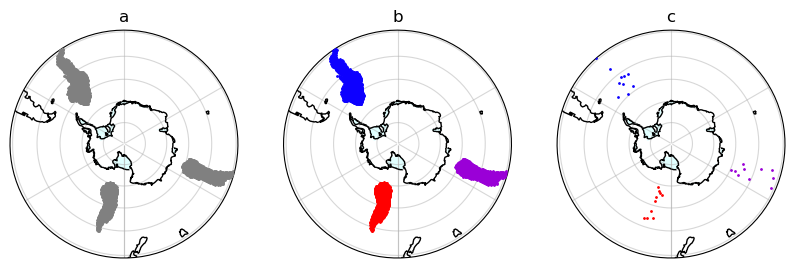

In [15]:
time = df.iloc[9].time

# instantiate the animation
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))

unique_clusters = df['cluster'].unique()
color_mapping = {unique_clusters[j]:prism(j/12) for j in range(len(unique_clusters)) }

if (time == df.time).any():
    dat = df[df['time'] == time]
    n_clusts = dat.shape[0]

    for i in range(n_clusts):
        cluster = dat['cluster'].iloc[i]
        ax[0].scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color='gray', zorder=30)
        ax[1].scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)
        ax[2].scatter(dat['rep_lons'].iloc[i], dat['rep_lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)

for i in range(len(ax)):

    ax[i].set_extent([-180,180,-90,-39], ccrs.PlateCarree())
    ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
    ax[i].add_feature(ice_shelf_poly,linewidth=3)
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax[i].add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax[i].coastlines(resolution='110m',linewidth=1,zorder=32)

    
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax[i].set_boundary(circle, transform=ax[i].transAxes)
    ax[i].gridlines(alpha=0.5, zorder=33)
    
    time_ts = pd.Timestamp(time)
    
ax[0].set_title('a')
ax[1].set_title('b')
ax[2].set_title('c')

plt.savefig('../output/spatial_clustering.png', bbox_inches='tight')

## Stage 2: Spatiotemporal Clustering

In [30]:
unpacked_df = cluster_obj.unpack_df(df, 'cluster')
unpacked_df = unpacked_df[unpacked_df.time.dt.day == 8]
unpacked_df = unpacked_df[unpacked_df.time.dt.hour % 6 == 0]
ais_mask = np.radians(np.array(list(load_ais('../input_data/antarctic_masks/', points=True))))

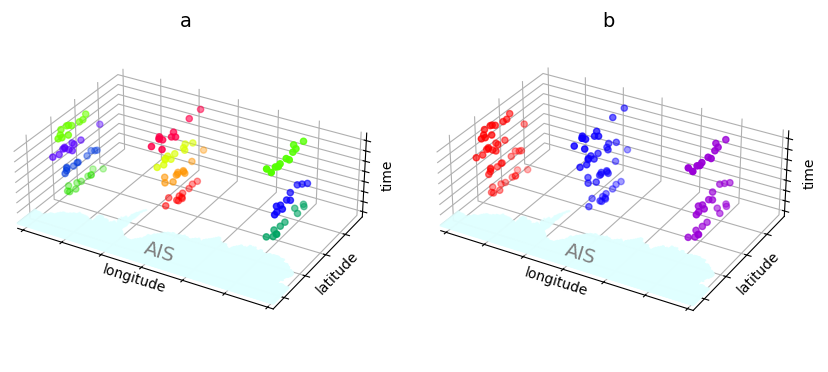

In [33]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,2,2, projection='3d')
ax.scatter(unpacked_df.lon, unpacked_df.lat, unpacked_df.time.dt.hour, c=prism((unpacked_df.cluster-1)/12))
ax.scatter(ais_mask[:,1], ais_mask[:,0], 0, c='lightcyan', s=0.5, zorder=30)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel('longitude', labelpad=-12)
ax.set_ylabel('latitude', labelpad=-12)
ax.set_zlabel('time', rotation=90, labelpad=-12)
ax.axes.set_ylim3d(bottom=min(ais_mask[:,0]))
ax.axes.set_xlim3d(left=min(ais_mask[:,1]))
ax.axes.set_xlim3d(right=max(ais_mask[:,1]))
ax.view_init(azim=-60, elev=30)
ax.set_box_aspect((1.45, 1, 0.5))
ax.text(x=0, y=-1.5, z=0, s='AIS', zorder=31, c='gray', zdir='x', fontsize=14)
ax.set_title('b', fontsize=14, y=1.01)

ax = fig.add_subplot(1,2,1, projection='3d')
ax.scatter(unpacked_df.lon, unpacked_df.lat, unpacked_df.time.dt.hour, c=prism((unpacked_df.space_cluster-1)/20))
ax.scatter(ais_mask[:,1], ais_mask[:,0], 0, c='lightcyan', s=0.5)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel('longitude', labelpad=-12)
ax.set_ylabel('latitude', labelpad=-12)
ax.set_zlabel('time', rotation=90, labelpad=-12)
ax.axes.set_ylim3d(bottom=min(ais_mask[:,0]))
ax.axes.set_xlim3d(left=min(ais_mask[:,1]))
ax.axes.set_xlim3d(right=max(ais_mask[:,1]))
ax.view_init(azim=-60, elev=30)
ax.set_title('a', fontsize=14, y=1.01)
ax.set_box_aspect((1.5, 1, 0.5))
ax.text(x=0, y=-1.5, z=0, s='AIS', zorder=31, c='gray', zdir='x', fontsize=14);

plt.savefig('../output/spatiotemporal_stitching.png', bbox_inches='tight')